# 🛒 Rossmann Retail Sales Forecasting
## Notebook 3: Model Training & Evaluation

**Author:** Cephas Adams Kumah  
**Dataset:** Rossmann Store Sales (Kaggle)  
**Models:** Random Forest · XGBoost  
**Objective:** Predict daily store sales across 1,115 stores using engineered time-series features

---
| Attribute | Detail |
|---|---|
| Training Records | 752,277 |
| Test Records | 58,611 |
| Features | 23 |
| Test Period | Jun – Jul 2015 |

## 1. Imports & Data Loading

The feature-engineered dataset generated in **Notebook 2** is loaded for model development. The `Date` column is converted back to the `datetime` data type to support chronological train-test splitting.

After removing observations with insufficient historical data for lag and rolling feature creation, the final modelling dataset contains **810,888 records** across **36 columns**.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

import xgboost as xgb  
import warnings

warnings.filterwarnings('ignore')
# Load feature-engineered dataset
df = pd.read_csv('../data/sales_features.csv')

# Restore Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

print(f"Loaded: {df.shape}")

Loaded: (810888, 36)


## 2.  Define Features & Target

Twenty-three input features are selected to train the forecasting models. These features are grouped into five categories:

- **Lag features:** Capture historical sales patterns from previous trading periods.
- **Rolling statistics:** Summarize recent sales trends and reduce short-term fluctuations.
- **Calendar features:** Encode seasonality and date-related patterns, such as month, quarter, and day of the week.
- **Store attributes:** Describe store characteristics, including store type, assortment, competition distance, and promotional programs.
- **Promotional signals:** Capture the effect of active promotions and school holidays on daily sales.

The target variable is **`Sales`**, which represents the daily revenue generated by each store in euros.

> ⚠️ **Leakage Prevention:** All lag and rolling features were generated using `.shift(1)` before computing rolling statistics. This ensures that every prediction is based solely on historical information and prevents future sales data from leaking into the model.

In [3]:
# Define model inputs and prediction target
features = [
    'Store','DayOfWeek','Promo','SchoolHoliday',
    'Year','Month','Day','WeekOfYear','Quarter',
    'IsWeekend','IsMonthStart','IsMonthEnd',
    'StoreType_enc','Assortment_enc','StateHoliday_enc',
    'CompetitionDistance','Promo2',
    'Sales_Lag_7','Sales_Lag_14','Sales_Lag_28',
    'Rolling_Mean_7', 'Rolling_Mean_30','Rolling_Std_7'
]
x = df[features]
y = df['Sales']

print(f"Features: {len(features)}")
print("Target: Sales")
print(f"X shape: {x.shape}")
print(f"y shape: {y.shape}")

Features: 23
Target: Sales
X shape: (810888, 23)
y shape: (810888,)


## 3. Time-Based Train/Test Split

A **chronological train-test split** is used instead of random sampling to reflect real-world forecasting conditions. In time-series problems, random splits can introduce **data leakage** by allowing the model to learn from future observations, resulting in overly optimistic performance metrics.

The dataset is divided as follows:

- **Training set:** January 2013 to May 2015 (**752,277 records**)
- **Test set:** June 2015 to July 2015 (**58,611 records**)

This approach ensures that the model is trained exclusively on historical data and evaluated on unseen future observations, providing a realistic assessment of forecasting performance.

In [4]:
# Split data chronologically to prevent future information from leaking into training
split_date = '2015-06-01'

train_mask = df['Date'] < split_date
test_mask = df['Date']  >= split_date

x_train = x[train_mask]
x_test  = x[test_mask]
y_train = y[train_mask]
y_test  = y[test_mask]

print(f"Training rows: {len(x_train):,}")
print(f"Test rows: {len(x_test):,}")

print(f"Training period: {df[train_mask]['Date'].min().date()} to {df[train_mask]['Date'].max().date()}")
print(f"Testing period: {df[test_mask]['Date'].min().date()} to {df[test_mask]['Date'].max().date()}")

Training rows: 752,277
Test rows: 58,611
Training period: 2013-01-31 to 2015-05-31
Testing period: 2015-06-01 to 2015-07-31


## 4. Train Random Forest

A **Random Forest Regressor** is trained as the baseline forecasting model. Random Forest is an ensemble learning algorithm that constructs multiple decision trees using random subsets of the training data and input features. Predictions from all trees are then averaged to produce the final sales forecast, helping to improve generalization and reduce overfitting.

### Model Configuration

- **`n_estimators=100`**: Builds 100 decision trees to improve prediction stability.
- **`max_depth=10`**: Restricts tree depth to control model complexity and reduce overfitting.
- **`min_samples_leaf=10`**: Requires a minimum of 10 observations in each leaf node, resulting in smoother and more robust predictions.
- **`random_state=42`**: Ensures reproducible results across multiple runs.
- **`n_jobs=-1`**: Utilizes all available CPU cores to speed up model training through parallel processing.

The trained model is evaluated on the unseen test set using **Root Mean Squared Error (RMSE)** and **Mean Absolute Percentage Error (MAPE)**.

In [5]:
print("Training Random Forest...")
# Train baseline tree-based regression model
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(x_train, y_train)

# Generate predictions on the future test period
rf_preds = rf.predict(x_test)

#Evaluate forecasting accuracy 
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mape = mean_absolute_percentage_error(y_test, rf_preds) * 100

print("Random Foest Results:")
print(f"RMSE: €{rf_rmse:,.0f}")
print(f"MAPE: {rf_mape:.1f}%")

Training Random Forest...
Random Foest Results:
RMSE: €1,097
MAPE: 12.1%


## 5. Train XGBoost

**Extreme Gradient Boosting (XGBoost)** is trained as the primary forecasting model. Unlike Random Forest, which builds decision trees independently in parallel, XGBoost constructs trees sequentially. Each new tree is trained to correct the prediction errors made by the previous trees, resulting in progressively improved model performance.

### Model Configuration

- **`n_estimators=300`**: Builds 300 boosting rounds to progressively improve prediction accuracy.
- **`max_depth=6`**: Limits the depth of each tree to control model complexity and reduce overfitting.
- **`learning_rate=0.05`**: Uses a small learning rate so that each tree makes gradual improvements, leading to better generalization.
- **`subsample=0.8`**: Randomly samples 80% of the training observations for each boosting round to improve robustness and reduce overfitting.
- **`colsample_bytree=0.8`**: Randomly samples 80% of the input features when constructing each tree, increasing model diversity.
- **`random_state=42`**: Ensures reproducible training results.
- **`n_jobs=-1`**: Utilizes all available CPU cores for faster model training.

The model is evaluated on the unseen test set using **Root Mean Squared Error (RMSE)** and **Mean Absolute Percentage Error (MAPE)** to assess forecasting accuracy.

In [6]:
print("Training XGBoot...")
# Train gradient boosting model on historical sales data
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    x_train, y_train,
    eval_set=[(x_test, y_test)],
    verbose=50
)
# Generate sales predictions for the test period
xgb_preds=xgb_model.predict(x_test)

# Evaluate forecasting performance
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mape = mean_absolute_percentage_error(y_test, xgb_preds) * 100

print(f"\nXGBoot Results:")
print(f"RMSE: €{xgb_rmse:,.0f}")
print(f"MAPE: {xgb_mape:.1f}%")   

Training XGBoot...
[0]	validation_0-rmse:3004.54422
[50]	validation_0-rmse:1145.26028
[100]	validation_0-rmse:1051.52141
[150]	validation_0-rmse:1015.77482
[200]	validation_0-rmse:992.29114
[250]	validation_0-rmse:978.59173
[299]	validation_0-rmse:973.48120

XGBoot Results:
RMSE: €973
MAPE: 10.4%


## 6. Model Comparison

The forecasting models are evaluated using two complementary performance metrics:

- **Root Mean Squared Error (RMSE):** Measures the average prediction error in euros. RMSE places greater emphasis on larger errors, making it useful for identifying models that produce more consistent forecasts. Lower values indicate better performance.
- **Mean Absolute Percentage Error (MAPE):** Measures the average prediction error as a percentage of actual sales. This metric is scale-independent and easier for business stakeholders to interpret. Lower values indicate higher forecasting accuracy.

The comparison shows that **XGBoost** achieves lower RMSE and MAPE than the Random Forest baseline, demonstrating superior predictive performance. Based on these results, **XGBoost is selected as the final forecasting model** for subsequent analysis and dashboard development.

In [7]:
# Compare model performance using forecasting error metrics
print("=" * 40)
print("MODEL COMPARSION")
print("=" * 40)

print(f"{'Model':<20} {'RMSE':>10} {'MAPE':>10}")
print("=" * 40)

print("-" * 40)
print(f"{'Random Forest':<20} €{rf_rmse:>8,.0f} {rf_mape:>9.1f}%")
print(f"{'XGBoost':<20} €{xgb_rmse:>8,.0f} {xgb_mape:>9.1f}%")
print("=" * 40)

best = 'XGBoost' if xgb_rmse < rf_rmse else 'Random Forest'
print(f"\nBest model: {best}")
print(f"RMSE improvement: €{rf_rmse - xgb_rmse:,.0f}")
print(f"MAPE improvement: {rf_mape - xgb_mape:.1f} percentage points")

MODEL COMPARSION
Model                      RMSE       MAPE
----------------------------------------
Random Forest        €   1,097      12.1%
XGBoost              €     973      10.4%

Best model: XGBoost
RMSE improvement: €123
MAPE improvement: 1.7 percentage points


## 7. Feature Importance Analysis

XGBoost assigns an importance score to each feature based on how frequently and effectively it is used to split the data during model training. Features with higher importance scores contribute more to the model's predictive performance.

The feature importance analysis highlights the key drivers of daily store sales:

- **Rolling statistics** are the most influential features, indicating that recent sales momentum is the strongest predictor of future sales.
- **Promo** is the most important business-controlled feature, demonstrating the significant impact of promotional campaigns on sales performance.
- **Lag features** rank highly, confirming that historical sales patterns provide valuable information for forecasting future demand.

These findings align with retail forecasting principles, where recent sales behaviour and promotional activity are strong indicators of short-term sales performance.

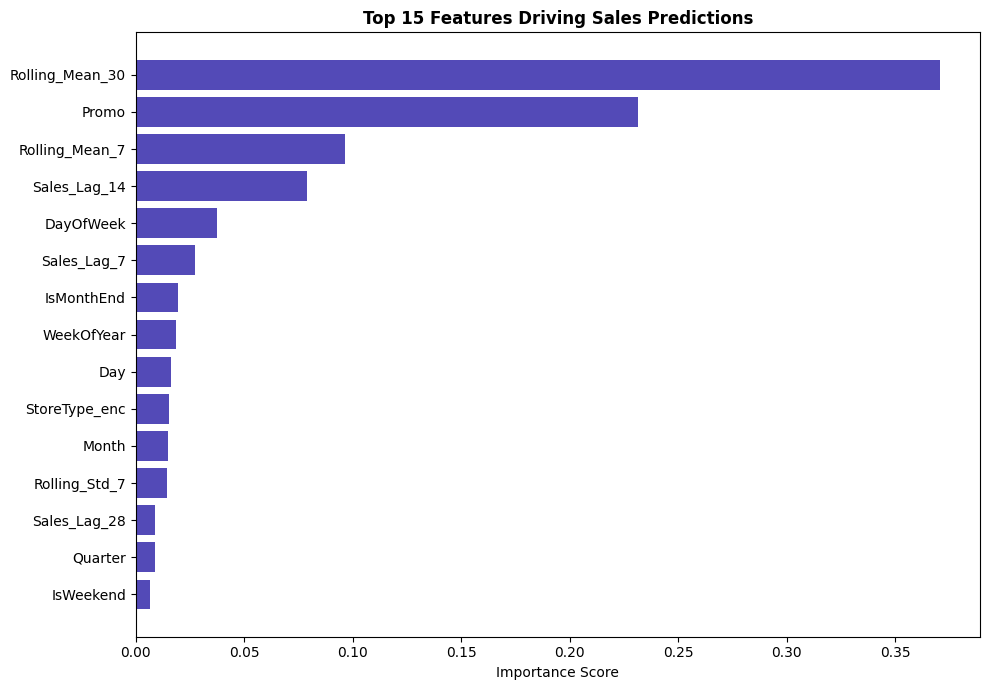

Feature importance saved.
        feature  importance
Rolling_Mean_30    0.370486
          Promo    0.231246
 Rolling_Mean_7    0.096290
   Sales_Lag_14    0.079077
      DayOfWeek    0.037555
    Sales_Lag_7    0.027182
     IsMonthEnd    0.019630
     WeekOfYear    0.018446
            Day    0.016176
  StoreType_enc    0.015265


In [8]:
# Extract and rank the most influential features from the XGBoost model
importance = pd.DataFrame({
    'feature': features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
plt.barh(importance['feature'][::-1],
         importance['importance'][::-1],
         color='#534AB7'
)
plt.title('Top 15 Features Driving Sales Predictions', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
# Save feature importance chart and table
plt.savefig('../visauls/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

importance.to_csv('../data/feature_importance.csv', index=False)
print("Feature importance saved.")
print(importance.head(10).to_string(index=False))


## 8. Actual vs. Predicted Sales

To evaluate forecast quality over time, daily sales predictions are aggregated across all stores and compared with the corresponding actual sales. Plotting both series provides a visual assessment of how closely the model captures overall sales trends throughout the test period.

A well-performing forecasting model should exhibit the following characteristics:

- The **predicted sales** closely follow the **actual sales** across the entire test period.
- Major peaks and troughs in daily sales are accurately captured, indicating that the model learns underlying demand patterns.
- Only small deviations exist between the two lines, suggesting minimal systematic overprediction or underprediction.

The close alignment between the actual and predicted sales curves demonstrates that the XGBoost model generalizes well to unseen data and provides reliable forecasts for short-term retail sales planning.

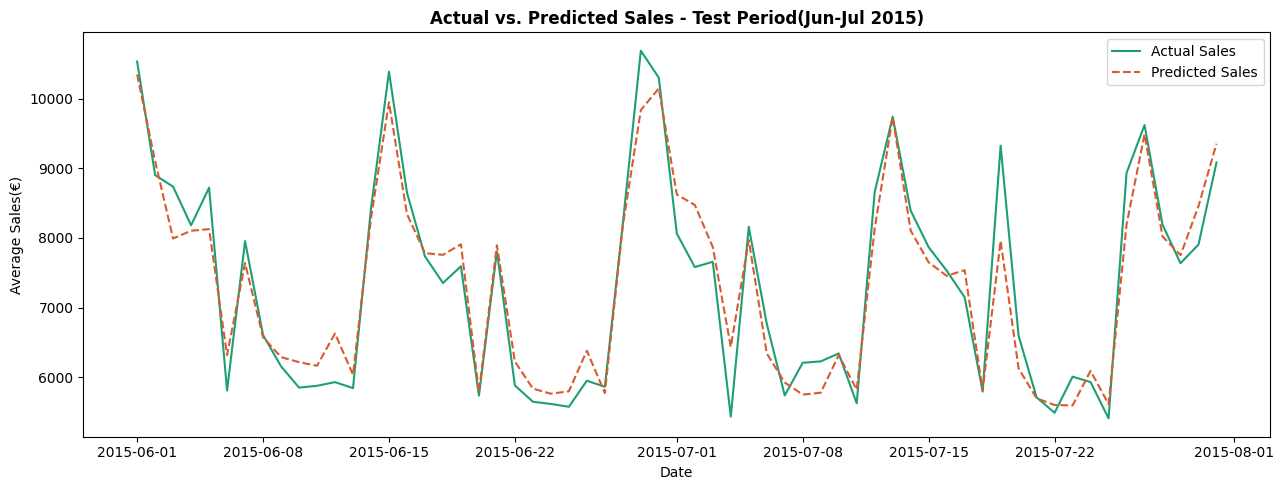

Chart saved


In [12]:
# Compare actual and predicted sales during the holdout period
sample = pd.DataFrame({
    'Date': df[test_mask]['Date'].values,
    'Actual': y_test.values,
    'Predicted': xgb_preds
}).sort_values('Date')

# Aggregate daily results to improve readability of the trend comparison
store_sample = sample.groupby('Date').mean().reset_index()

plt.figure(figsize=(13,5))

plt.plot(
    store_sample['Date'],
    store_sample['Actual'],
    label='Actual Sales',
    color='#1D9E75',
    linewidth=1.5,
    
)

plt.plot(
    store_sample['Date'],
    store_sample['Predicted'],
    label='Predicted Sales',
    color='#D85A30',
    linewidth=1.5,
    linestyle='--'
)

plt.title(
    'Actual vs. Predicted Sales - Test Period(Jun-Jul 2015)', 
    fontweight='bold'
)
plt.xlabel('Date')
plt.ylabel('Average Sales(€)')
plt.legend()
plt.tight_layout()

# Save visualization for reporting and portfolio documentation
plt.savefig(
    '../visuals/actual_vs_predicted.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Chart saved")

## 9. Export Predictions

The final test-set predictions are exported to **`sales_predictions.csv`** for downstream analysis and dashboard development. Alongside the original dataset, three diagnostic columns are added to support model evaluation:

- **`Predicted_Sales`**: Sales predicted by the XGBoost model.
- **`Error`**: Prediction error, calculated as **Actual Sales − Predicted Sales**.
- **`Error_Pct`**: Absolute percentage error for each prediction.

These additional fields provide a straightforward way to assess forecast accuracy at the individual record level and identify where the model performs well or deviates from actual sales.

The exported dataset serves as the primary data source for the Power BI dashboard, enabling interactive analysis of forecast accuracy, model performance, and store-level insights across all three report pages.

In [13]:
# Save test-period predictions with error diagnostics
output = df[test_mask].copy()
output['Predicted_Sales'] = xgb_preds
output['Error'] = output['Sales'] - output['Predicted_Sales']
output['Error_Pct'] = abs(output['Error']) / output['Sales'] * 100

output.to_csv('../data/sales_predictions.csv', index=False)

print(f"Prediction saved: {output.shape}")
print(f"\nSample output:")
print(output[['Store', 'Date', 'Sales', 'Predicted_Sales',
              'Error', 'Error_Pct']].head(10))

Prediction saved: (58611, 39)

Sample output:
     Store       Date  Sales  Predicted_Sales        Error  Error_Pct
699      1 2015-06-01   5774      6908.070312 -1134.070312  19.640982
700      1 2015-06-02   5450      5771.142578  -321.142578   5.892524
701      1 2015-06-03   5809      4910.338867   898.661133  15.470152
702      1 2015-06-05   5384      5115.587402   268.412598   4.985375
703      1 2015-06-06   4183      4566.743164  -383.743164   9.173874
704      1 2015-06-08   4071      4060.221436    10.778564   0.264765
705      1 2015-06-09   4102      3870.136475   231.863525   5.652451
706      1 2015-06-10   3591      3903.620361  -312.620361   8.705663
707      1 2015-06-11   3627      3907.406982  -280.406982   7.731100
708      1 2015-06-12   3695      4150.747070  -455.747070  12.334156


---
## 📊 Final Results Summary

The performance of the two forecasting models is summarized below.

| Model | RMSE | MAPE | Accuracy |
|---|---:|---:|---:|
| Random Forest | €1,097 | 12.1% | 87.9% |
| **XGBoost ✓** | **€973** | **10.4%** | **89.6%** |

### Key Findings

- **XGBoost** achieved the best overall forecasting performance and was selected as the final model.
- **RMSE improved by €124 per store per day** compared with the Random Forest baseline.
- **MAPE decreased by 1.7 percentage points**, indicating more accurate percentage-based forecasts.

> ✅ The final predictions were exported to **`sales_predictions.csv`**, which serves as the primary data source for the interactive Power BI dashboard.